Наиболее протяжённый участок: (28, 58) -> (188, 218)
Длина: 226.3 пикселей


(np.float64(-0.5), np.float64(224.5), np.float64(224.5), np.float64(-0.5))

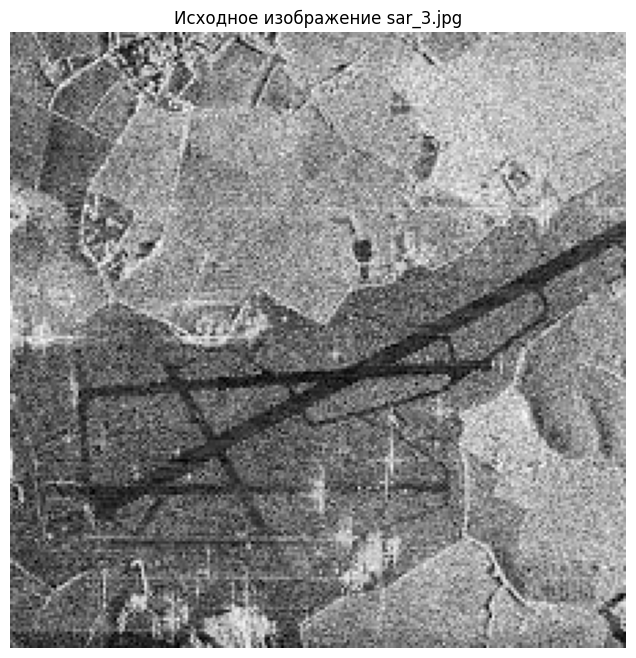

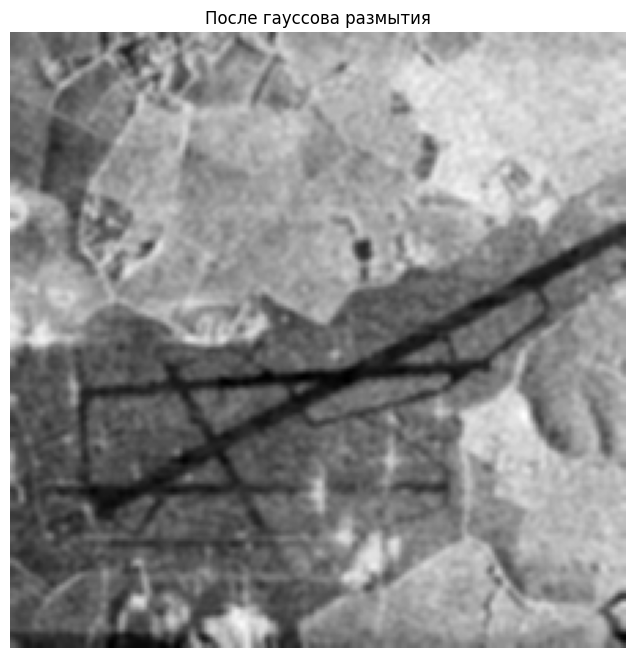

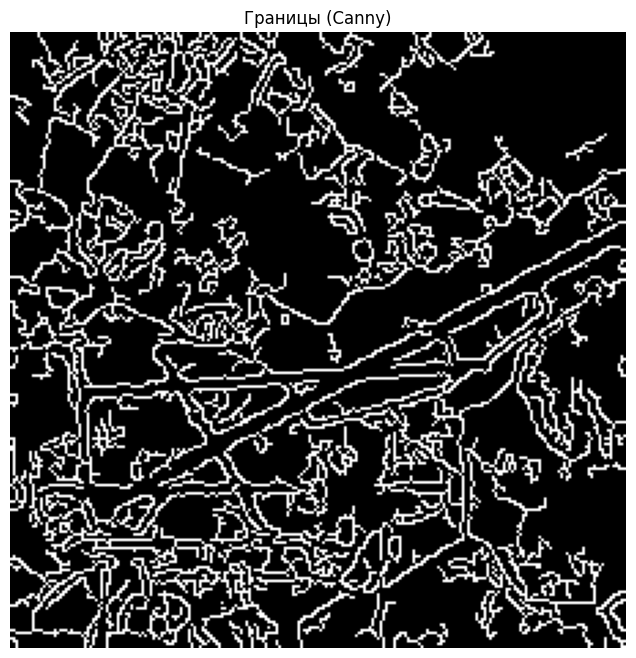

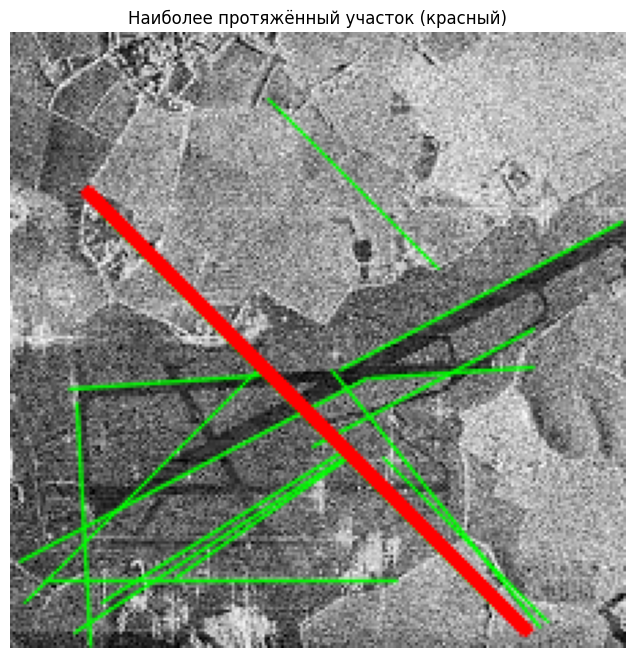

In [4]:

# Задание 1

import numpy as np
import cv2
import matplotlib.pyplot as plt
import math

image = cv2.imread('sar_3.jpg')
image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Исходное изображение sar_3.jpg')
plt.axis('off')


image_blur = cv2.GaussianBlur(image_gray, (5, 5), 0)

plt.figure(figsize=(8, 8))
plt.imshow(image_blur, cmap='gray')
plt.title('После гауссова размытия')
plt.axis('off')

canny = cv2.Canny(image_blur, 50, 150, apertureSize=3)

plt.figure(figsize=(8, 8))
plt.imshow(canny, cmap='gray')
plt.title('Границы (Canny)')
plt.axis('off')

linesP = cv2.HoughLinesP(
    canny,
    rho=1,
    theta=np.pi / 180,
    threshold=80,
    minLineLength=60,
    maxLineGap=10
)


image_lines = image.copy()
longest_length = 0
longest_line = None

if linesP is not None:
    for i in range(len(linesP)):
        x1, y1, x2, y2 = linesP[i].ravel()[:4]
        length = math.hypot(x2 - x1, y2 - y1)

        cv2.line(image_lines, (x1, y1), (x2, y2), (0, 255, 0), 1, cv2.LINE_AA)
        if length > longest_length:
            longest_length = length
            longest_line = (x1, y1, x2, y2)

if longest_line is not None:
    x1, y1, x2, y2 = longest_line
    cv2.line(image_lines, (x1, y1), (x2, y2), (0, 0, 255), 4, cv2.LINE_AA)
    print(f'Наиболее протяжённый участок: ({x1}, {y1}) -> ({x2}, {y2})')
    print(f'Длина: {longest_length:.1f} пикселей')

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(image_lines, cv2.COLOR_BGR2RGB))
plt.title('Наиболее протяжённый участок (красный)')
plt.axis('off')

Порог, найденный методом Отсу: 129.0
Компонента дорожной полосы: label=1, вытянутость=1.00


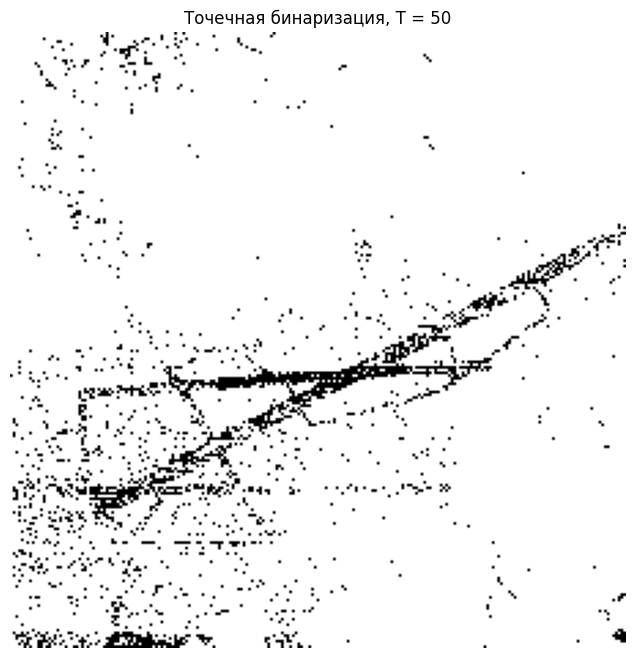

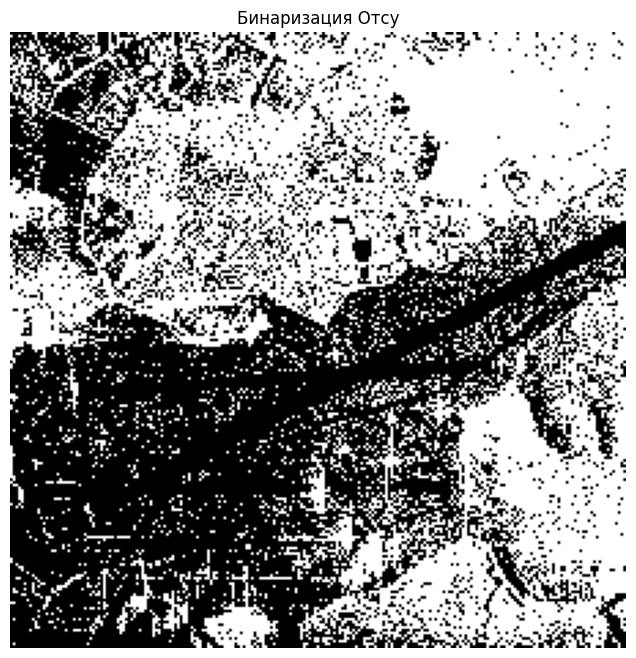

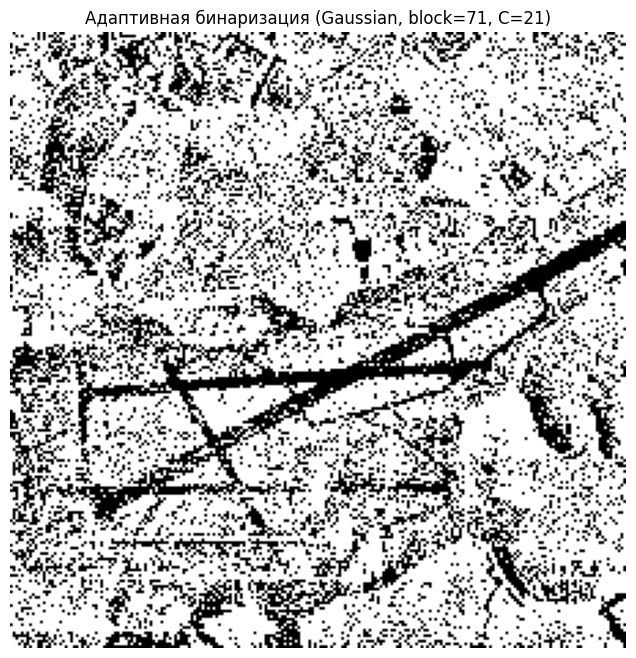

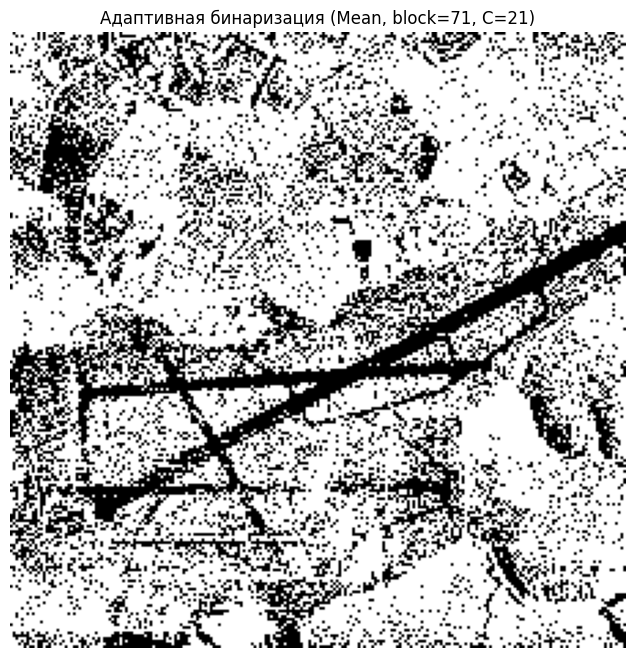

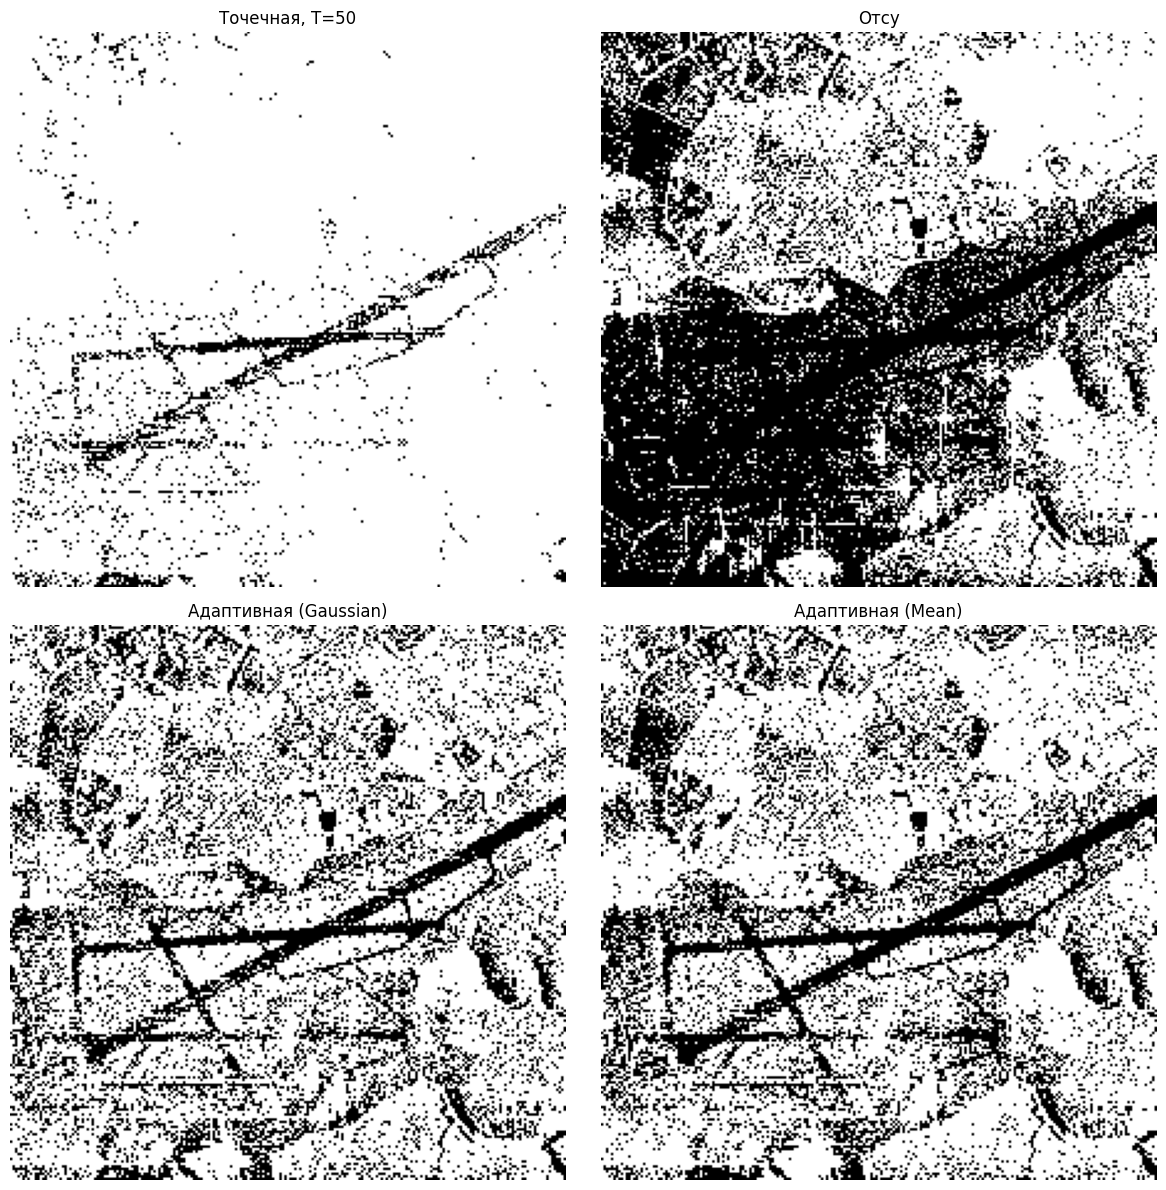

In [6]:

# Задание 2

import copy

bin_img = copy.deepcopy(image_gray)
T = 50
bin_img[image_gray < T] = 0
bin_img[image_gray >= T] = 255

plt.figure(figsize=(8, 8))
plt.imshow(bin_img, cmap='gray')
plt.title(f'Точечная бинаризация, T = {T}')
plt.axis('off')

_, th_otsu = cv2.threshold(
    image_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)
print('Порог, найденный методом Отсу:', _)

plt.figure(figsize=(8, 8))
plt.imshow(th_otsu, cmap='gray')
plt.title('Бинаризация Отсу')
plt.axis('off')

th_adapt = cv2.adaptiveThreshold(
    image_gray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    71, 21
)

plt.figure(figsize=(8, 8))
plt.imshow(th_adapt, cmap='gray')
plt.title('Адаптивная бинаризация (Gaussian, block=71, C=21)')
plt.axis('off')

th_adapt_mean = cv2.adaptiveThreshold(
    image_gray, 255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    71, 21
)

plt.figure(figsize=(8, 8))
plt.imshow(th_adapt_mean, cmap='gray')
plt.title('Адаптивная бинаризация (Mean, block=71, C=21)')
plt.axis('off')

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0, 0].imshow(bin_img, cmap='gray')
axes[0, 0].set_title(f'Точечная, T={T}')
axes[0, 0].axis('off')

axes[0, 1].imshow(th_otsu, cmap='gray')
axes[0, 1].set_title('Отсу')
axes[0, 1].axis('off')

axes[1, 0].imshow(th_adapt, cmap='gray')
axes[1, 0].set_title('Адаптивная (Gaussian)')
axes[1, 0].axis('off')

axes[1, 1].imshow(th_adapt_mean, cmap='gray')
axes[1, 1].set_title('Адаптивная (Mean)')
axes[1, 1].axis('off')

plt.tight_layout()


road = th_otsu.copy()

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
road = cv2.morphologyEx(road, cv2.MORPH_CLOSE, kernel)
road = cv2.morphologyEx(road, cv2.MORPH_OPEN, kernel)

num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    road, connectivity=8
)

best_label = -1
best_elongation = 0

for i in range(1, num_labels):
    x, y, w, h, area = stats[i]
    if area < 500:
        continue
    elongation = max(w, h) / (min(w, h) + 1e-6)
    if elongation > best_elongation:
        best_elongation = elongation
        best_label = i

print(f'Компонента дорожной полосы: label={best_label}, '
      f'вытянутость={best_elongation:.2f}')


